In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons

X, y = make_moons(
    n_samples=1000,
    noise=0.20,
    random_state=42
)

df = pd.DataFrame(X, columns=["feature_1", "feature_2"])
df["target"] = y

df.to_csv("svm_practice.csv", index=False)

print(df.head())
print(df.shape)
print(df["target"].value_counts())

   feature_1  feature_2  target
0  -0.111667   0.520224       1
1   1.142650  -0.342577       1
2   0.795558  -0.011442       1
3   0.111827  -0.551932       1
4  -0.816466   0.543996       0
(1000, 3)
target
1    500
0    500
Name: count, dtype: int64


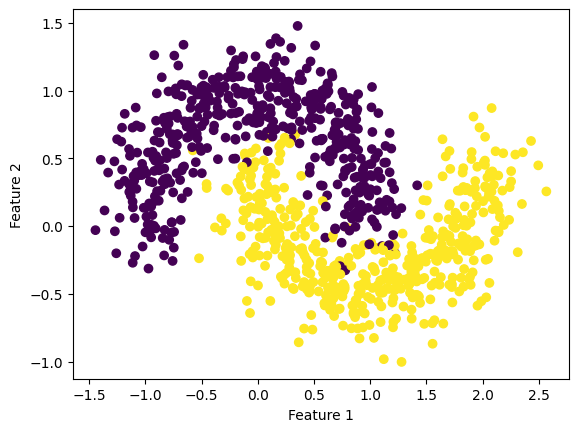

In [2]:
import matplotlib.pyplot as plt

plt.scatter(
    df["feature_1"],
    df["feature_2"],
    c=df["target"]
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df[["feature_1", "feature_2"]], df["target"], test_size=0.2, random_state=42)

In [6]:
from sklearn.svm import SVC
svc=SVC(kernel="linear", C=1.0, random_state=42)

In [7]:
svc.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [8]:
y_pred = svc.predict(X_test)

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [13]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.85      0.85       100
           1       0.85      0.86      0.86       100

    accuracy                           0.85       200
   macro avg       0.86      0.85      0.85       200
weighted avg       0.86      0.85      0.85       200

[[85 15]
 [14 86]]
0.855


using kernel = rbf

In [14]:
rbf = SVC(kernel="rbf", C=1.0, random_state=42)


In [15]:
rbf.fit(X_train, y_train)
y_pred_rbf = rbf.predict(X_test)

In [17]:
print(classification_report(y_test, y_pred_rbf))
print(confusion_matrix(y_test, y_pred_rbf))
print(accuracy_score(y_test, y_pred_rbf))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       100
           1       0.98      0.98      0.98       100

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200

[[98  2]
 [ 2 98]]
0.98


Accuracy impoved significantly when we used rbf kernel instead of linear kernel. This is because the data is not linearly separable and rbf kernel is able to capture the non-linear decision boundary.

# SVM Kernel (poly)

In [18]:
kernel = "poly"
poly = SVC(kernel=kernel, C=1.0, random_state=42)
poly.fit(X_train, y_train)
y_pred_poly = poly.predict(X_test)

In [19]:
print(classification_report(y_test, y_pred_poly))
print(confusion_matrix(y_test, y_pred_poly))
print(accuracy_score(y_test, y_pred_poly))

              precision    recall  f1-score   support

           0       0.98      0.83      0.90       100
           1       0.85      0.98      0.91       100

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.90       200
weighted avg       0.91      0.91      0.90       200

[[83 17]
 [ 2 98]]
0.905
